# Figure 2: what do the experimental Ising and XY sweeps look like?

This notebook produces the base panel of manuscript Fig. 2 (`fig:quantum_data`), writing
`Plots/Fig2.pdf` and an alternate version, `Plots/Fig2_alt.pdf`.

**Caveat.** The file the manuscript actually includes is
`final_figures/Fig2_w-snapshots_NEW_print_santized.pdf`. That file starts from this
notebook's `Fig2.pdf` output, adds representative snapshot images to panels (a) and (c) by
hand, and sanitizes the PDF color space for print, all outside this notebook. Re-running
this notebook reproduces the base panel, not the published composite.

### The physics

Both datasets are raw snapshots from Rydberg-atom quantum simulators that realize a
spin-1/2 lattice model through the Rydberg blockade mechanism. The Ising dataset drives an
$8\times8$ array through the transverse-field Ising Hamiltonian described in the main text,
sweeping the detuning $\delta$ and Rabi frequency $\Omega$ quasi-adiabatically from a
$Z$-polarized paramagnet. Snapshots are measured in the $Z$ basis over
$t\in[0,6]\,\mu\mathrm{s}$ at $0.2\,\mu\mathrm{s}$ steps.

As $\delta$ increases, the system first crosses smoothly out of near-full $Z$-polarization.
Later in the same sweep it crosses the paramagnet-to-antiferromagnet quantum phase
transition proper. Panel (b) below shows correlators sensitive to both changes.

The XY dataset drives a $6\times7$ array through a dipolar XY Hamiltonian with a staggered
longitudinal field $\delta_{\mathrm{XY}}$. The system starts in a N\'eel state, and the
staggered field is ramped toward zero, connecting to a state with ferromagnetic in-plane
($XY$) correlations. Snapshots are measured in both the $X$ and $Z$ bases over
$t\in[0,8]\,\mu\mathrm{s}$ at irregular intervals.

Panels (b) and (d) track local spin correlators $C[P]$ across each sweep: for Ising, the
$Z$-magnetization, the rotation-averaged nearest-neighbor correlation, and the staggered
magnetization; for XY, nearest-neighbor correlations plus the in-plane ferromagnetic
magnetization squared $(m^X)^2$. These are the same correlator patterns TetrisCNN later
rediscovers from its bottleneck; this figure shows they already track the sweep on their
own, independent of any learned model.

### What it reads

Three dataset variants are loaded through `create_datasets(cf)`: `Paris_Ising`,
`Paris_XY_Z` and `Paris_XY_X`. These read the raw experimental snapshot
tree under `datasets/`, which is not distributed with the repository (see the README's
"Data and trained runs" section and `datasets/README.md`); a reader without that tree
cannot execute this notebook as it stands.


In [1]:
import os
from pathlib import Path

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.models import *
from tetriscnn.utils import *
from tetriscnn.datasets import *
from tetriscnn.plots import *

import math
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from collections import defaultdict

import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.gridspec as gs

DEVICE = "cpu"

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

### Loading the four dataset variants

`create_datasets(cf)` builds a `PhaseDataset` from the same `AttrDict` configuration the
training code uses, here with `cf.even_split = True` so every sweep time point is
represented (see `docs/CONFIGURATION.md`, `even_split`). Four variants are
constructed: the Ising $Z$-basis dataset, and the XY $Z$-basis and $X$-basis datasets
separately.

All three feed the panels drawn later in this notebook. The per-basis
$\delta_{\mathrm{XY}}$ comparison that App. A 2 makes (Fig. 8) is produced by
`FiguresApp_A.ipynb`, not here.


In [2]:

cf = AttrDict() # Describes all the 'knobs' of an experiment
cf.seed = 42
set_seeds(cf.seed)

cf.task = "regression"        # choose between "regression" and "classification"
cf.label_param = "t"      # label parameter for the Paris datasets; 't', 'delta', 'omega' for Ising, 't' for XY, 'beta' for ILGT
cf.normalize_labels = True    # normalize labels to [0, 1] range, only for regression
cf.label_subset_count = None   # number between 0 and 100
cf.filter_t_values = None

cf.data_fraction = 1.0
cf.param_cutoffs = {"delta" : 6, "omega" : 0}         # NB: for XZ, delta = 11 gives divergence
cf.even_split = True
cf.samples_per_pt_cap = None


cf.dataset = "Paris_Ising"  
Ising_dataset, _ = create_datasets(cf)
Ising_loader = DataLoader(Ising_dataset, batch_size=1, shuffle=True) # type: ignore
Ising_deltas = np.array(list( Ising_dataset.processor.delta_dict.values() )) # type: ignore
Ising_omegas = np.array(list( Ising_dataset.processor.omega_dict.values() )) # type: ignore
Ising_times = Ising_dataset.unique_times    # type: ignore


cf.dataset = "Paris_XY_Z" 
XYZ_dataset, _ = create_datasets(cf)
XYZ_loader = DataLoader(XYZ_dataset, batch_size=1, shuffle=True) # type: ignore
XYZ_deltas = np.array(list( XYZ_dataset.processor.delta_dict_z.values() )) # type: ignore
XYZ_times = XYZ_dataset.unique_times # type: ignore


cf.dataset = "Paris_XY_X" 
XYX_dataset, _ = create_datasets(cf)
XYX_loader = DataLoader(XYX_dataset, batch_size=1, shuffle=True) # type: ignore
XYX_deltas = np.array(list( XYX_dataset.processor.delta_dict_x.values() )) # type: ignore
XYX_times = XYX_dataset.unique_times #


[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples
times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])
directory:  <repo>/datasets/experimental/XY/6x7_atoms_Z_ferro_video_15MHz_tau0p3_16032022_7_0_defects_0_holes



[Even Split] Found 21 time points
[Even Split] Samples per time point: min=371, max=6539, median=842.0
[Even Split] After per-time-point 70/30 split: 18837 train, 8087 val samples
times shape: 18837, labels shape: torch.Size([18837])
times shape: 8087, labels shape: torch.Size([8087])
directory:  <repo>/datasets/experimental/XY/6x7_atoms_X_ferro_video_15MHz_tau0p3_17032022_0_defects_0_holes



[Even Split] Found 13 time points
[Even Split] Samples per time point: min=792, max=2574, median=1000.0
[Even Split] After per-time-point 70/30 split: 11532 train, 4952 val samples
times shape: 11532, labels shape: torch.Size([11532])
times shape: 4952, labels shape: torch.Size([4952])


### Picking representative snapshots for the inset images

The caption of Fig. 2 shows representative snapshots inside panels (a) and (c). This cell
searches each dataloader for a snapshot at a few target sweep times and stores one per
match. It is slow, since it iterates the full dataloader once per label until enough
matches are found for every requested time.

The returned dictionaries (`Ising_samples`, `XYZ_samples`, `XYX_samples`) are not consumed
anywhere else in this notebook: they are the source the snapshot images are picked from
before being placed into panels (a),(c) of the composited figure by hand. Nothing in the
saved `Fig2.pdf` depends on this cell; skipping it changes nothing about the base panel.


In [3]:
Ising_sample_times = [600., 1200., 6000.]
XYZ_sample_times = [0., 500., 6000.]
XYX_sample_times = [0., 500., 6000.]

def find_representative_samples(dataset, dataloader, target_values=[600., 1200., 6000.]):

    unique_labels = dataset.unique_labels
    no_labels = len(unique_labels)

    selected_samples = defaultdict(list)

    for i, label in enumerate(unique_labels):
        count = 0
        for batch in dataloader:
            x, y = batch
            x = x.to("cpu").numpy()
            y = y.to("cpu").numpy()
            
            for j in range(x.shape[0]):

                t = denormalize01(y[j].item(), dataset.y_min, dataset.y_max).cpu().numpy()

                if (math.isclose(t, target_values[0], abs_tol=0.05) or 
                    math.isclose(t, target_values[1], abs_tol=0.05) or 
                    math.isclose(t, target_values[2], abs_tol=0.05)) and selected_samples[np.round(t)] == []:

                    print(f"Found sample for t={t} at label index {j}")
                    selected_samples[np.round(t)].append(x[j,0])
                    count += 1
                    if count > 2:
                        break
                if count > 2:
                    break
            
            if count > 2:
                break
        if count > 2:
            break

    return selected_samples

Ising_samples = find_representative_samples(Ising_dataset, Ising_loader, target_values=Ising_sample_times)
XYZ_samples = find_representative_samples(XYZ_dataset, XYZ_loader, target_values=XYZ_sample_times)
XYX_samples = find_representative_samples(XYX_dataset, XYX_loader, target_values=XYX_sample_times)

Found sample for t=600.0 at label index 0
Found sample for t=6000.0 at label index 0
Found sample for t=1200.0 at label index 0
Found sample for t=0.0 at label index 0
Found sample for t=500.0 at label index 0
Found sample for t=6000.0 at label index 0
Found sample for t=500.0 at label index 0
Found sample for t=0.0 at label index 0
Found sample for t=6000.0 at label index 0


### Saving the inset snapshots as individual images

The samples found above still need to become the small black-and-white lattice
images that sit inside panels (a) and (c) of the composited figure. `save_lattice_image`
below renders one snapshot as a bare, axis-free image, one pixel per lattice site, and
writes it as an SVG so it composites cleanly at any size. The nine files this produces
(three Ising times, three XY-$Z$ times, three XY-$X$ times) are placed into panels
(a),(c) by hand afterward; nothing downstream in this notebook reads them back.


In [4]:
from pathlib import Path
from matplotlib.colors import ListedColormap

# Global scale: inches per lattice site, so the Ising (8x8) and XY (6x7) images
# come out at a consistent pixel size relative to each other.
pixel_scale = 0.2
snapshot_cmap = ListedColormap(["#fef7f4", "#6a6a6a"])
SNAPSHOT_DIR = Path("Plots/SVG/Fig2_snapshots")
SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)

def save_lattice_image(data, filename):
    fig_width = data.shape[1] * pixel_scale
    fig_height = data.shape[0] * pixel_scale

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    # 'nearest' keeps the pixels crisp (no blurring); 'equal' keeps them square.
    ax.imshow(data, aspect="equal", interpolation="nearest", cmap=snapshot_cmap)
    ax.axis("off")
    fig.savefig(filename, format="svg", bbox_inches="tight", pad_inches=0)
    plt.close(fig)

for t in Ising_sample_times:
    save_lattice_image(Ising_samples[np.round(t)][0], SNAPSHOT_DIR / f"Ising_t_{int(t)}.svg")
for t in XYZ_sample_times:
    save_lattice_image(XYZ_samples[np.round(t)][0], SNAPSHOT_DIR / f"XY_Z_t_{int(t)}.svg")
for t in XYX_sample_times:
    save_lattice_image(XYX_samples[np.round(t)][0], SNAPSHOT_DIR / f"XY_X_t_{int(t)}.svg")

### Correlators computed per snapshot, then averaged over the sweep

The functions below compute one spin correlator per snapshot: the staggered
magnetization, the plain magnetization, the nearest-neighbor correlation (optionally
restricted to one direction), and the in-plane squared magnetization used in panel (d).
`compute_observables` then loops over every snapshot in a dataloader, groups the
per-snapshot values by their true sweep time, and reduces each group to a mean, a standard
deviation, and a standard error.

The plots later in this notebook shade by the **standard deviation** across snapshots at
each sweep point, not the standard error; the shaded band is therefore the actual spread of
single-snapshot values, not a measure of how precisely the mean is known.

`in_plane_mag_sq` reproduces the manuscript's connected in-plane magnetization squared,
$(m^X)_c^2 = \langle C^X[\blacksquare]^2\rangle - \langle C^X[\blacksquare]\rangle^2$; the
derivation is worked out symbolically in the next cell. Because it requires an ensemble
average taken *before* squaring, this connected correlator cannot be computed from a single
snapshot, only over the sweep, which is exactly the caveat the main text raises about what a
single-snapshot network can and cannot access.


In [5]:
def staggered_magnetization(spins):
    N = spins.size
    Lx, Ly = spins.squeeze().shape
    checkerboard = np.fromfunction(lambda i, j: (-1)**(i+j), (Lx, Ly))
    return np.abs(np.sum(spins * checkerboard) / N)

def magnetization(spins):
    N = spins.size
    return np.sum(spins) / N

import numpy as np

def nn_correlation(spins, horizontal=True, vertical=True):
    """
    Nearest-neighbor correlation function for 2D spins (±1).
    Open boundary conditions (neighbors outside are treated as zero).
    """
    assert horizontal or vertical, "At least one direction must be True"
    Lx, Ly = spins.shape
    corr = 0.0
    z = 0

    # right neighbors
    if horizontal:
        corr += np.sum(spins[:, :-1] * spins[:, 1:])
        z += 1

    # down neighbors
    if vertical:
        corr += np.sum(spins[:-1, :] * spins[1:, :])
        z += 1

    N = spins.size
    
    return corr / (N * z)

def connected_correlator(snapshots):
    """snapshots: (n_shots, Nx, Ny) array of ±1 values"""
    snapshots = np.expand_dims(snapshots, 0) if snapshots.ndim == 2 else snapshots
    sx = np.mean(snapshots, axis=0)  # <σ_i^x>
    # <σ_i^x σ_j^x> via FFT convolution over shots
    corr = np.mean(snapshots[:, :, :, None, None] * snapshots[:, None, None, :, :], axis=0)
    return corr - sx[:, :, None, None] * sx[None, None, :, :]  # (Nx,Ny,Nx,Ny)

def in_plane_mag_sq(snapshots, mode='FM'):
    snapshots = np.expand_dims(snapshots, 0) if snapshots.ndim == 2 else snapshots
    Nx, Ny = snapshots.shape[1], snapshots.shape[2]
    ix, iy = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
    sign = (-1) ** (ix + iy) if mode == 'AFM' else np.ones((Nx, Ny))
    
    C = connected_correlator(snapshots)  # (Nx,Ny,Nx,Ny)
    N = Nx * Ny
    m2 = np.sum(sign[:, :, None, None] * sign[None, None, :, :] * C) / N**2
    return m2


def squared_magnetization(spins):
    N = spins.size
    mag = np.sum(spins) / N
    return mag**2

Given:
$$
\widetilde C_{i, j}^x=\left\langle\sigma_i^x \sigma_j^x\right\rangle-\left\langle\sigma_i^x\right\rangle\left\langle\sigma_j^x\right\rangle
$$
$$
m_{\mathrm{FM} / \mathrm{AFM}}^2=\frac{1}{N^2} \sum_{i, j}( \pm 1)^{\left(r_i^x+r_i^y\right) / a} \widetilde C_{i, j}^x
$$
We have FM, so
$$
\begin{aligned}
m_{\mathrm{FM}}^2&=\frac{1}{N^2} \sum_{i, j} \widetilde C_{i, j}^x \\
&= \frac{1}{N^2} \left( \sum_{i, j} \left\langle\sigma_i^x \sigma_j^x\right\rangle-\left[\sum_{i}\left\langle\sigma_i^x\right\rangle\right]^2 \right)\\
&=  \left\langle\frac{1}{N^2}  \sum_{i, j} \sigma_i^x \sigma_j^x\right\rangle-\left\langle C_X[\blacksquare]\right\rangle^2 \\
&=  \left\langle C_X[\blacksquare]^2\right\rangle-\left\langle C_X[\blacksquare]\right\rangle^2 \\
% &=\frac{1}{N^2} \left( \sum_{i, j} \frac{1}{N_y}\sum_{n\in\Gamma_y} \sigma_i^x(y) \sigma_j^x(y)-\left[ \sum_{i}\frac{1}{N_y}\sum_{n\in\Gamma_y} \sigma_i^x \right]^2 \right)
\end{aligned}
$$


In [6]:
observables = {
    'ms':   staggered_magnetization,
    'm':    magnetization,
    'nn':   nn_correlation,
    'nn_h': lambda s: nn_correlation(s, horizontal=True, vertical=False),
    'nn_v': lambda s: nn_correlation(s, horizontal=False, vertical=True),
    'm2':  in_plane_mag_sq,
    'm2_term1' : squared_magnetization
}

def avg_and_sem(data_dict):
    avg = {lbl: np.mean(data_dict[lbl]) for lbl in data_dict}
    sem = {lbl: np.std(data_dict[lbl], ddof=1) / np.sqrt(len(data_dict[lbl]))
        for lbl in data_dict}
    return avg, sem


def compute_observables(loader, dataset):
    data = {k: defaultdict(list) for k in observables}
    for spins, label in loader:
        spins = spins.squeeze().numpy()
        t = label.item()
        for k, fn in observables.items():
            data[k][t].append(fn(spins))

    times = sorted(next(iter(data.values())).keys())
    vals = {}
    for k, v in data.items():
        vals[k] = {
            'mean': np.array([np.mean(v[t]) for t in times]),
            'std':  np.array([np.std(v[t], ddof=1) for t in times]),
            'ste':  np.array([np.std(v[t], ddof=1) / np.sqrt(len(v[t])) for t in times]),
        }

    for k in list(vals.keys()):
        raw = [np.array(data[k][t]) for t in times]
        y   = [(s - s.mean())**2 for s in raw]
        vals[k]['var_ste'] = np.array([v.std(ddof=1) / np.sqrt(len(v)) for v in y])

    times_denorm = [denormalize01(t, dataset.y_min, dataset.y_max) / 1000. for t in times]
    times_denorm = [t.cpu().numpy() for t in times_denorm]

    return times_denorm, vals


times_TFI, obs_TFI = compute_observables(Ising_loader, Ising_dataset)
times_XYZ, obs_XYZ = compute_observables(XYZ_loader, XYZ_dataset)
times_XYX, obs_XYX = compute_observables(XYX_loader, XYX_dataset)
# 

## Drawing the figure

The two figures below share the same panel layout, `paper.mplstyle`, and color palette
(`colors.py`, the styling shared across all paper figures; see `docs/NOTEBOOKS.md`).
The vertical dashed lines mark the sweep times used for the
representative-snapshot search above, the times where a snapshot is inserted by hand into
panels (a) and (c) of the composited figure.

The two saved files differ only in how panel (d) is drawn. `Fig2.pdf`, the version used in
the manuscript, plots the connected in-plane magnetization squared $(m^X)_c^2$ derived
above alongside the naive, disconnected $\langle C^X[\blacksquare]^2\rangle$, making the
distinction between the two visible. `Fig2_alt.pdf` instead plots the raw (unsquared)
$X$-basis magnetization $\langle C^X[\blacksquare]\rangle$ in its place; it is kept as a
saved alternative, not the panel the manuscript caption describes.


In [7]:
plt.style.use(PAPER_MPLSTYLE)

DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

In [8]:
from tetriscnn.colors import COLORS, colors

In [9]:
color_delta = COLORS["blackish"]
color_omega = COLORS["reddish"]
color_deltaxy = COLORS["blackish"]
colorMg = COLORS["blue"]
colorNN = COLORS["green"]
colorMs = COLORS["red"]
colorNNh = COLORS["green_dark"]
colorNNv = COLORS["gray"]

# ADDED FOR M2:
colorM2 = COLORS["purple"]
colorM2_term1 = COLORS["orange"]

red = COLORS["red"]   # bare alias used by the Fig2_alt panel below

### `Fig2.pdf`: the panel used in the manuscript

`subplot_mosaic` lays out panel (a) top-left, (c) top-right, (b) bottom-left, and (d)
bottom-right, matching the manuscript layout. `ax1b` is a twin $y$-axis sharing panel (a)'s
$x$-axis, so $\delta$ and $\Omega$ can share one panel with independent scales.


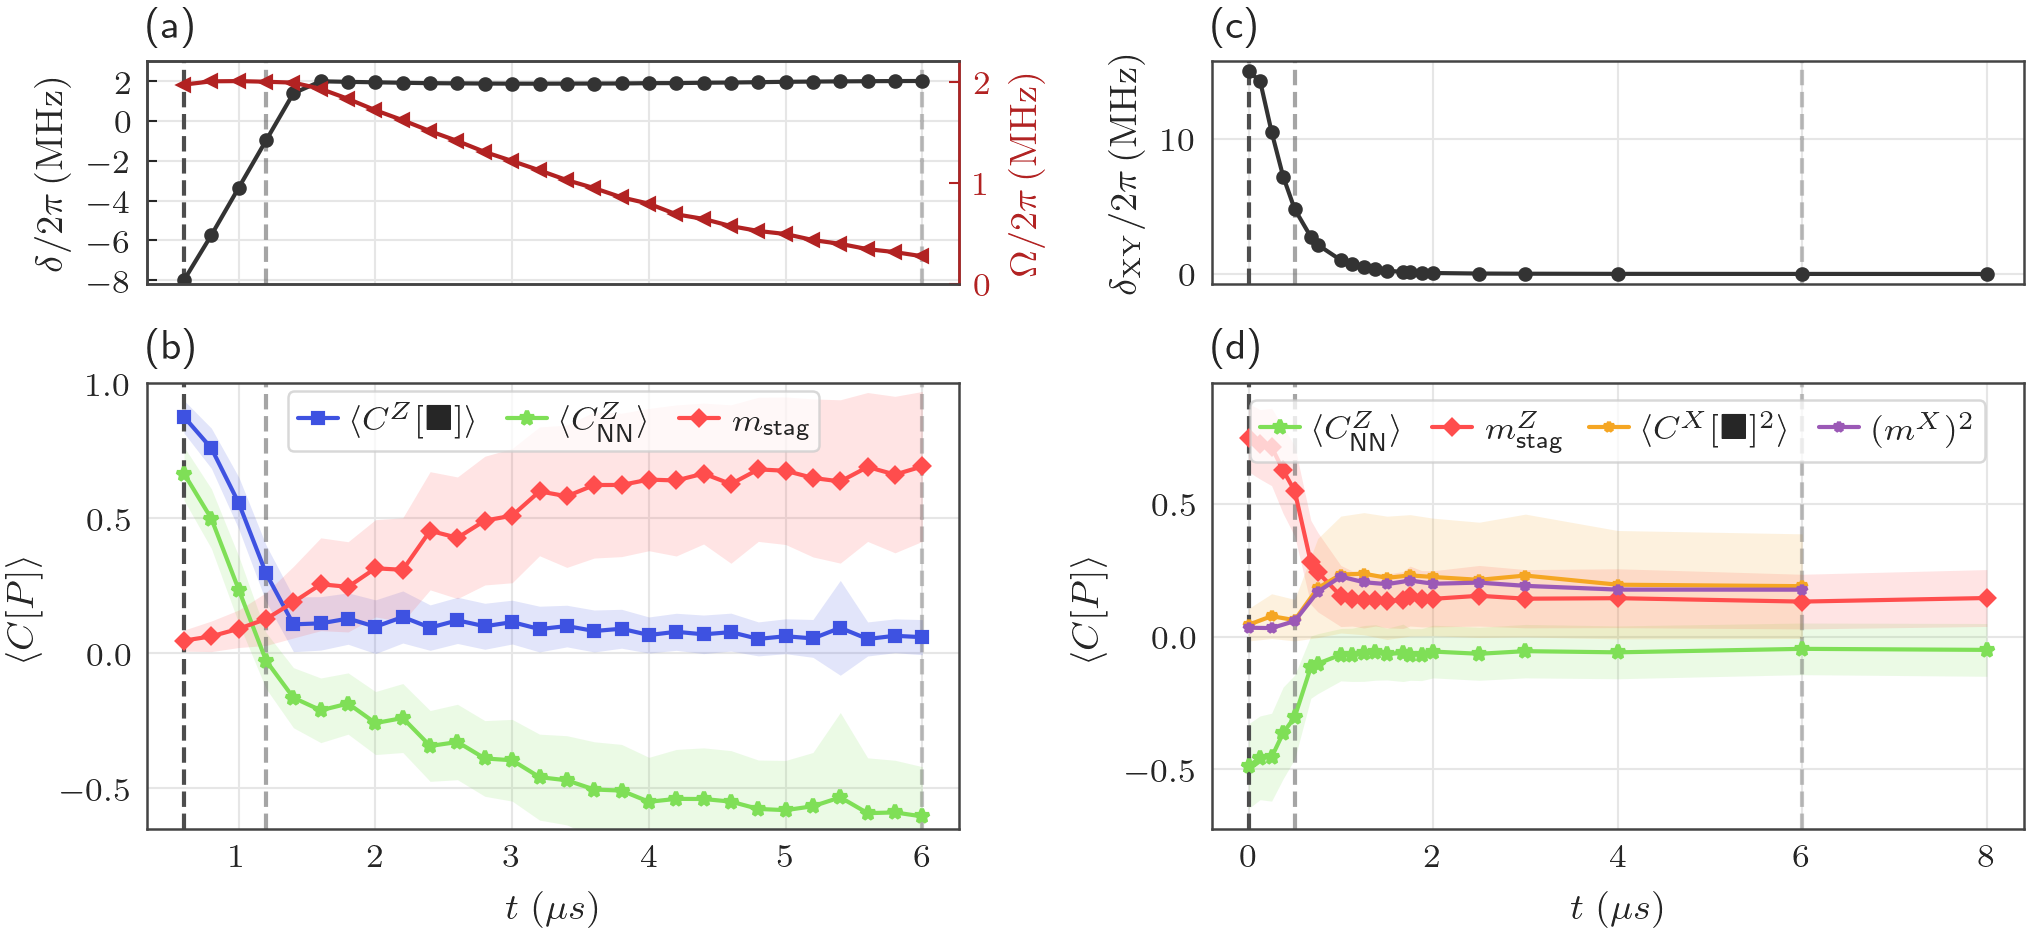

In [10]:
nn_h_shape = kernel_to_latex_pattern([(2,1), 1, 1, None, 1], equation_env=False, full_latex=True)
nn_v_shape = kernel_to_latex_pattern([(1,2), 1, 1, None, 1], equation_env=False, full_latex=True)
mag_shape = kernel_to_latex_pattern([(1,1), 1, 1, None, 1], equation_env=False, full_latex=True)



mag_label = rf"$\langle C^Z[{mag_shape}]\rangle$"
nn_label = r"$\langle C^Z_{\text{NN}}\rangle$"
nn_h_label = rf"$\langle C^Z[{nn_h_shape}]\rangle$"
nn_v_label = rf"$\langle C^Z[{nn_v_shape}]\rangle$"
m_stag_label = r"$\langle m^Z_\text{stag}\rangle$"

m2_label = r"$(m^X)^2$"
m2_term1_label = r"$\langle C^X[\blacksquare]^2\rangle$"
magX_label = rf"$\langle C^X[{mag_shape}]\rangle$"

fig, axs = plt.subplot_mosaic(
    [["A", "C"], ["B", "D"]],
    figsize=(DOUBLE_WIDTH, DOUBLE_WIDTH / golden_ratio * 0.75),
    height_ratios=(0.5,1.0)
)
ax1b = axs["A"].twinx()

# in ax1 and ax3, plot vertical lines at the times where the representative samples were taken
for i,t in enumerate(Ising_sample_times): # type: ignore
    t_denorm = t/1000.
    axs["A"].axvline(t_denorm, color="0.3", linestyle="--", alpha = 1/(i+1))
    axs["B"].axvline(t_denorm, color="0.3", linestyle="--", alpha = 1/(i+1))

for i,t in enumerate(XYZ_sample_times): # type: ignore
    t_denorm = t/1000.
    axs["C"].axvline(t_denorm, color="0.3", linestyle="--", alpha = 1/(i+1))
    axs["D"].axvline(t_denorm, color="0.3", linestyle="--", alpha = 1/(i+1))

linedelta, = axs["A"].plot(times_TFI, Ising_deltas, label=r'$\delta$', color=color_delta,marker ="o", ms=2.5, linestyle="-")
lineomega, = ax1b.plot(times_TFI, Ising_omegas, label=r'$\Omega$', color=color_omega, marker ="<", ms=2.5, linestyle="-")

linedelta2, = axs["C"].plot(times_XYZ, XYZ_deltas, label=r'$\delta_{\mathrm{XY}}$', color=color_deltaxy, marker ="o", ms=2.5, linestyle="-")

# ========================================================================================================
# IMPORTANT: Comment out this block to get rid of the inset in panel C


def shade(ax, x, obs, key, color):
    m = obs[key]['mean']
    s = obs[key]['std']
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.15, linewidth=0)

axs["B"].plot(times_TFI, obs_TFI['m']['mean'],  marker="s",           label=mag_label,              color=colorMg)
shade(axs["B"], times_TFI, obs_TFI, 'm',  colorMg)
axs["B"].plot(times_TFI, obs_TFI['nn']['mean'], marker="*", ms=3.5,   label=nn_label,               color=colorNN)
shade(axs["B"], times_TFI, obs_TFI, 'nn', colorNN)
axs["B"].plot(times_TFI, obs_TFI['ms']['mean'], marker="D",           label=r"$m_{\text{stag}}$",   color=colorMs)
shade(axs["B"], times_TFI, obs_TFI, 'ms', colorMs)
axs["B"].set_ylim(-0.65, 1.0)

axs["D"].plot(times_XYZ, obs_XYZ['nn']['mean'],   marker="*", ms=3.5, label=nn_label,   color=colorNN)
shade(axs["D"], times_XYZ, obs_XYZ, 'nn',   colorNN)
axs["D"].plot(times_XYZ, obs_XYZ['ms']['mean'], marker="D",           label=r"$m^Z_{\text{stag}}$",   color=colorMs)
shade(axs["D"], times_XYZ, obs_XYZ, 'ms', colorMs)

axs["D"].plot(times_XYX, obs_XYX['m2_term1']['mean'], markersize=2.5, marker="*", label=m2_term1_label, color=colorM2_term1)
shade(axs["D"], times_XYX, obs_XYX, 'm2_term1', colorM2_term1)

axs["D"].plot(times_XYX, obs_XYX['m']['std']**2, markersize=2.5, marker="*", label=m2_label, color=colorM2)
axs["D"].fill_between(times_XYX,
    obs_XYX['m']['std']**2 - obs_XYX['m']['var_ste'],
    obs_XYX['m']['std']**2 + obs_XYX['m']['var_ste'],
    color=colorM2, alpha=0.15, linewidth=0)

handles1=[linedelta, lineomega]
handles2 =[linedelta2]
leg3 = axs["B"].legend(ncol=3, bbox_to_anchor=(0.5, 1.02), loc="upper center")#, columnspacing=columnspacing1)
leg4 = axs["D"].legend(ncol=4, loc="upper center")

axs["A"].set_ylabel(r"$\delta/2 \pi \, (\mathrm{MHz})$")
axs["A"].tick_params(axis="y")
axs["A"].set_ylim([-8.2,3])
axs["A"].set_yticks([-8,-6,-4,-2,0,2])

ax1b.set_ylabel(r"$\Omega/2 \pi \, (\mathrm{MHz})$", color=color_omega)
ax1b.tick_params(axis="y", color=color_omega)
ax1b.spines["right"].set_color(color_omega)
ax1b.set_ylim([0,2.2])
ax1b.set_yticks([0,1,2])

for tick in ax1b.yaxis.get_ticklabels():
    tick.set_color(color_omega)

#for ax in [ax1, ax1b, ax2, ax3, ax4]:

axs["A"].set_xticklabels([])  # hide x-ticks for top row
axs["C"].set_xticklabels([])  # hide x-ticks for top row
axs["B"].set_xlabel(r"$t\;(\mu s)$")
axs["D"].set_xlabel(r"$t\;(\mu s)$")
axs["B"].set_ylabel(r"$\langle C[P] \rangle$")
axs["D"].set_ylabel(r"$\langle C[P] \rangle$")
axs["C"].set_ylabel(r"$\delta_{\mathrm{XY}}/2 \pi \, (\mathrm{MHz})$ ")
axs["C"].tick_params(axis="y")

# titles
axs["A"].set_title("(a)", loc="left")

axs["C"].set_title("(c)", loc="left")

axs["B"].set_title("(b)", loc="left")
axs["D"].set_title("(d)", loc="left")

#for ax in [axs["B"], axs["D"]]:
#    for text, line in zip(legend.get_texts(), legend.get_lines()):

## --- Add light grid ---
#for ax in [ax1, ax2, ax3, ax4]:
#    # zorder=0 ensures the grid is behind the data points
#    ax.grid(True, which='major', axis='both', linestyle='-', 
#            linewidth=linewidth_grid, color='gray', alpha=0.2, zorder=0)

# Special handling for ax1b (twinx) to avoid double vertical grids
ax1b.grid(False)

# replace these with your actual image arrays
# save as pdf
fig.savefig("Plots/Fig2.pdf", bbox_inches='tight')

### `Fig2_alt.pdf`: swapping panel (d)'s order-parameter curve

Identical to the cell above except for panel (d), which now plots the raw $X$-basis
magnetization $\langle C^X[\blacksquare]\rangle$ instead of the squared, connected
correlator. This is the only panel where the two saved figures differ.


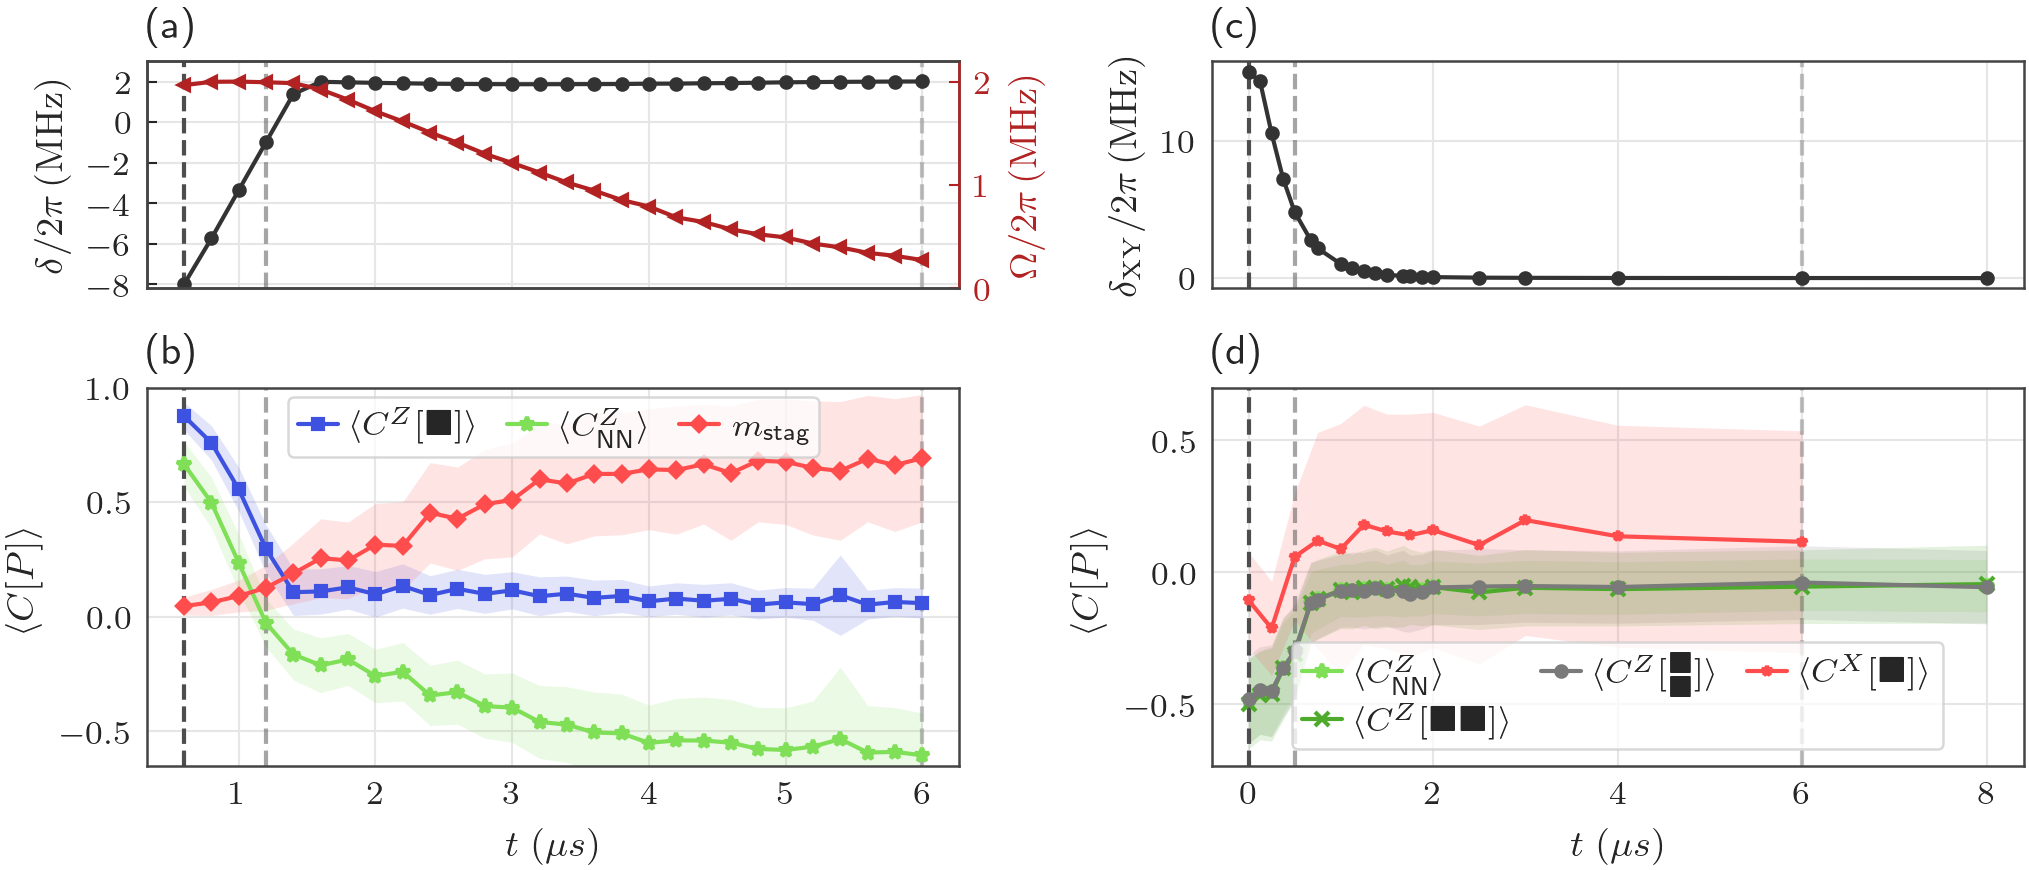

In [11]:
fig, axs = plt.subplot_mosaic(
    [["A", "C"], ["B", "D"]],
    figsize=(DOUBLE_WIDTH, DOUBLE_WIDTH / golden_ratio * 0.7),
    height_ratios=(0.6,1.0)
)
ax1b = axs["A"].twinx()

# in ax1 and ax3, plot vertical lines at the times where the representative samples were taken
for i,t in enumerate(Ising_sample_times): # type: ignore
    t_denorm = t/1000.
    axs["A"].axvline(t_denorm, color="0.3", linestyle="--", alpha = 1/(i+1))
    axs["B"].axvline(t_denorm, color="0.3", linestyle="--", alpha = 1/(i+1))

for i,t in enumerate(XYZ_sample_times): # type: ignore
    t_denorm = t/1000.
    axs["C"].axvline(t_denorm, color="0.3", linestyle="--", alpha = 1/(i+1))
    axs["D"].axvline(t_denorm, color="0.3", linestyle="--", alpha = 1/(i+1))

linedelta, = axs["A"].plot(times_TFI, Ising_deltas, label=r'$\delta$', color=color_delta,marker ="o", ms=2.5, linestyle="-")
lineomega, = ax1b.plot(times_TFI, Ising_omegas, label=r'$\Omega$', color=color_omega, marker ="<", ms=2.5, linestyle="-")

linedelta2, = axs["C"].plot(times_XYZ, XYZ_deltas, label=r'$\delta_{\mathrm{XY}}$', color=color_deltaxy, marker ="o", ms=2.5, linestyle="-")

# ========================================================================================================
# IMPORTANT: Comment out this block to get rid of the inset in panel C
def shade(ax, x, obs, key, color):
    m = obs[key]['mean']
    s = obs[key]['std']
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.15, linewidth=0)

axs["B"].plot(times_TFI, obs_TFI['m']['mean'],  marker="s",           label=mag_label,              color=colorMg)
shade(axs["B"], times_TFI, obs_TFI, 'm',  colorMg)
axs["B"].plot(times_TFI, obs_TFI['nn']['mean'], marker="*", ms=3.5,   label=nn_label,               color=colorNN)
shade(axs["B"], times_TFI, obs_TFI, 'nn', colorNN)
axs["B"].plot(times_TFI, obs_TFI['ms']['mean'], marker="D",           label=r"$m_{\text{stag}}$",   color=colorMs)
shade(axs["B"], times_TFI, obs_TFI, 'ms', colorMs)
axs["B"].set_ylim(-0.65, 1.0)

axs["D"].plot(times_XYZ, obs_XYZ['nn']['mean'],   marker="*", ms=3.5, label=nn_label,   color=colorNN)
shade(axs["D"], times_XYZ, obs_XYZ, 'nn',   colorNN)
axs["D"].plot(times_XYZ, obs_XYZ['nn_h']['mean'], marker="x", ms=3.5, label=nn_h_label, color=colorNNh)
shade(axs["D"], times_XYZ, obs_XYZ, 'nn_h', colorNNh)
axs["D"].plot(times_XYZ, obs_XYZ['nn_v']['mean'], marker="o", ms=2.5, label=nn_v_label, color=colorNNv)
shade(axs["D"], times_XYZ, obs_XYZ, 'nn_v', colorNNv)


# X magnetization
axs["D"].plot(times_XYX, obs_XYX['m']['mean'], markersize=2.5, marker="*", label=magX_label, color=red)
shade(axs["D"], times_XYX, obs_XYX, 'm', red)




handles1=[linedelta, lineomega]
handles2 =[linedelta2]
leg3 = axs["B"].legend(ncol=3, bbox_to_anchor=(0.5, 1.02), loc="upper center")#, columnspacing=columnspacing1)
leg4 = axs["D"].legend(ncol=3, loc="lower center")

axs["A"].set_ylabel(r"$\delta/2 \pi \, (\mathrm{MHz})$")
axs["A"].tick_params(axis="y")
axs["A"].set_ylim([-8.2,3])
axs["A"].set_yticks([-8,-6,-4,-2,0,2])

ax1b.set_ylabel(r"$\Omega/2 \pi \, (\mathrm{MHz})$", color=color_omega)
ax1b.tick_params(axis="y", color=color_omega)
ax1b.spines["right"].set_color(color_omega)
ax1b.set_ylim([0,2.2])
ax1b.set_yticks([0,1,2])

for tick in ax1b.yaxis.get_ticklabels():
    tick.set_color(color_omega)

#for ax in [ax1, ax1b, ax2, ax3, ax4]:

axs["A"].set_xticklabels([])  # hide x-ticks for top row
axs["C"].set_xticklabels([])  # hide x-ticks for top row
axs["B"].set_xlabel(r"$t\;(\mu s)$")
axs["D"].set_xlabel(r"$t\;(\mu s)$")
axs["B"].set_ylabel(r"$\langle C[P] \rangle$")
axs["D"].set_ylabel(r"$\langle C[P] \rangle$")
axs["C"].set_ylabel(r"$\delta_{\mathrm{XY}}/2 \pi \, (\mathrm{MHz})$ ")
axs["C"].tick_params(axis="y")

# titles
axs["A"].set_title("(a)", loc="left")

axs["C"].set_title("(c)", loc="left")

axs["B"].set_title("(b)", loc="left")
axs["D"].set_title("(d)", loc="left")

#for ax in [axs["B"], axs["D"]]:
#    for text, line in zip(legend.get_texts(), legend.get_lines()):

## --- Add light grid ---
#for ax in [ax1, ax2, ax3, ax4]:
#    # zorder=0 ensures the grid is behind the data points
#    ax.grid(True, which='major', axis='both', linestyle='-', 
#            linewidth=linewidth_grid, color='gray', alpha=0.2, zorder=0)

# Special handling for ax1b (twinx) to avoid double vertical grids
ax1b.grid(False)

# replace these with your actual image arrays
# save as pdf
fig.savefig("Plots/Fig2_alt.pdf", bbox_inches='tight')